In [1]:
import os
import re
import sys
import pandas as pd

sys.path.append('..')

from src.keywords import CATEGORY_KEYWORDS

In [2]:
# Import cleaned speech data
JPspeeches_df = pd.read_csv('../data/clean/combined_speeches_clean.csv')
JPspeeches_df.head(5)

,Unnamed: 0,speaker/title,date,text
0,0,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02 00:00:00,Having heard the sudden demise of His Majesty ...
1,1,Statement of Prime Minister Junichiro Koizumi,2001-08-13 00:00:00,"The day after tomorrow, August 15, is the fift..."
2,2,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23 00:00:00,Many lives were lost as a result of the terror...
3,3,Observation by Prime Minister Junichiro Koizum...,2002-04-21 00:00:00,Today I paid a visit to Yasukuni Shrine.\n\nTh...
4,4,"Message from Mr. Junichiro Koizumi, Prime Mini...",2002-04-28 00:00:00,On the occasion of the 50th anniversary of the...


In [3]:
# Drop na values in text
JPspeeches_pd_filtered = JPspeeches_df.dropna(subset=['text'])
JPspeeches_pd_filtered.head(5)

,Unnamed: 0,speaker/title,date,text
0,0,Statement of Prime Minister Junichiro Koizumi ...,2001-06-02 00:00:00,Having heard the sudden demise of His Majesty ...
1,1,Statement of Prime Minister Junichiro Koizumi,2001-08-13 00:00:00,"The day after tomorrow, August 15, is the fift..."
2,2,Remarks by Prime Minister Junichiro Koizumi at...,2001-09-23 00:00:00,Many lives were lost as a result of the terror...
3,3,Observation by Prime Minister Junichiro Koizum...,2002-04-21 00:00:00,Today I paid a visit to Yasukuni Shrine.\n\nTh...
4,4,"Message from Mr. Junichiro Koizumi, Prime Mini...",2002-04-28 00:00:00,On the occasion of the 50th anniversary of the...


In [4]:
# Count number of total articles
speeches_numrows = len(JPspeeches_pd_filtered)
speeches_numrows

576

In [5]:
# Clean csv info
JPspeeches_pd_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     576 non-null    int64 
 1   speaker/title  576 non-null    object
 2   date           576 non-null    object
 3   text           576 non-null    object
dtypes: int64(1), object(3)
memory usage: 18.1+ KB


## Graph

In [6]:
import importlib
from src.graph_articles import keyword_yearly_counts, plot_category

JPspeeches_df = pd.read_csv('../data/clean/combined_speeches_clean.csv')
JPnews_df = pd.read_csv('../data/clean/japan_news_cleaned.csv')

In [7]:
JPnews_df.head(5)

,source,date,title,author,text
0,The Japan Times,2001-01-01,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
1,The Japan Times,2001-01-01,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
2,The Japan Times,2001-01-01,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
3,The Japan Times,2001-01-01,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
4,The Japan Times,2001-01-01,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...


In [8]:
JPnews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36766 entries, 0 to 36765
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   source  36766 non-null  object
 1   date    36766 non-null  object
 2   title   36766 non-null  object
 3   author  12724 non-null  object
 4   text    36766 non-null  object
dtypes: object(5)
memory usage: 1.4+ MB


In [9]:
JPspeeches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     576 non-null    int64 
 1   speaker/title  576 non-null    object
 2   date           576 non-null    object
 3   text           576 non-null    object
dtypes: int64(1), object(3)
memory usage: 18.1+ KB


In [10]:
news_results = keyword_yearly_counts(JPnews_df)
speech_results = keyword_yearly_counts(JPspeeches_df)

In [11]:
news_results.head(15)

,date,article_count,category,total_articles,normalized
0,2001,1127,defense,12141,0.092826
1,2002,870,defense,9965,0.087306
2,2003,979,defense,9065,0.107998
3,2004,32,defense,224,0.142857
4,2005,29,defense,261,0.111111
5,2006,46,defense,445,0.103371
6,2007,83,defense,790,0.105063
7,2008,8,defense,95,0.084211
8,2009,8,defense,95,0.084211
9,2010,32,defense,318,0.100629


In [12]:
speech_results.tail(10)

,date,article_count,category,total_articles,normalized
74,2012,3,immigration,20,0.150000
75,2013,5,immigration,8,0.625000
76,2014,15,immigration,42,0.357143
77,2015,15,immigration,39,0.384615
78,2016,8,immigration,72,0.111111
79,2017,10,immigration,38,0.263158
80,2018,1,immigration,22,0.045455
81,2019,6,immigration,37,0.162162
82,2020,3,immigration,65,0.046154
83,2021,38,immigration,157,0.242038


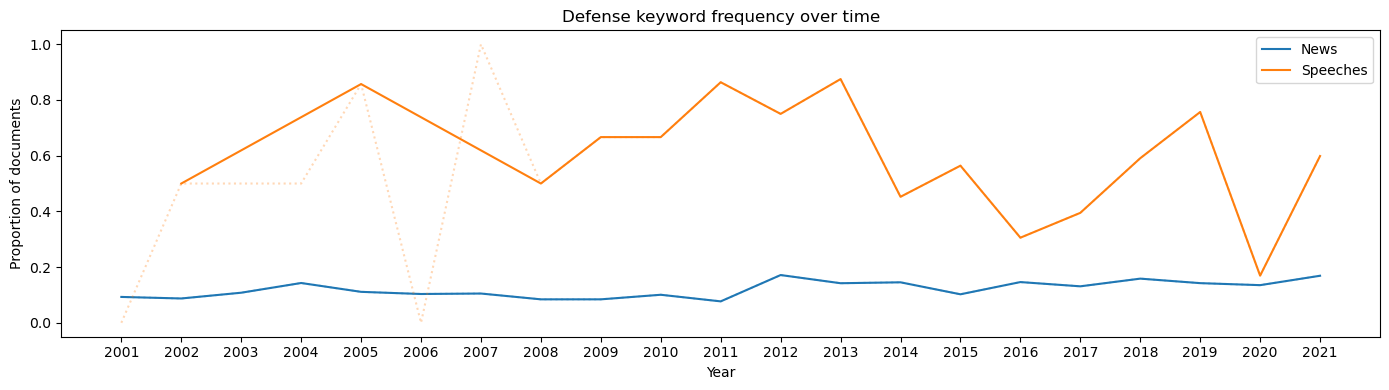

In [13]:
plot_category('defense', news_results, speech_results, labels=['News', 'Speeches'])

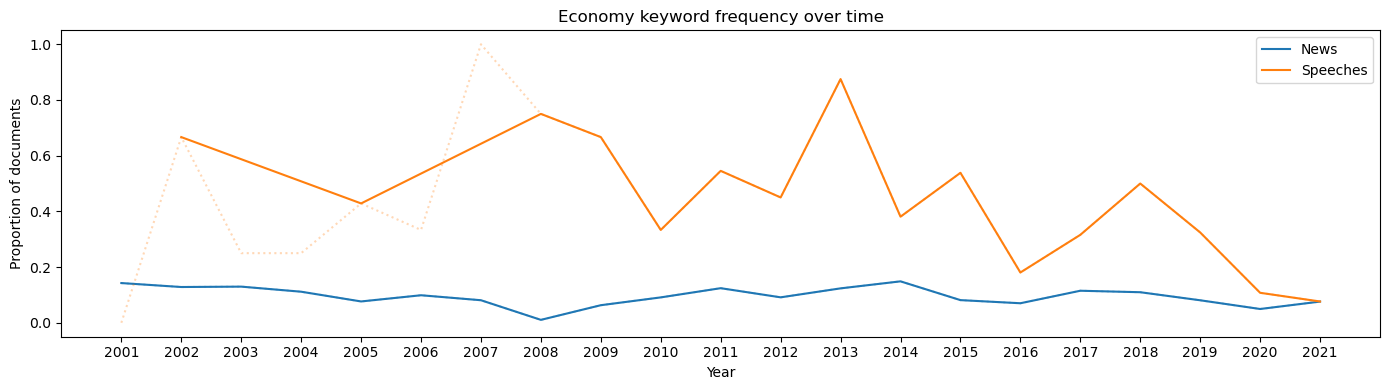

In [14]:
plot_category('economy', news_results, speech_results, labels=['News', 'Speeches'])

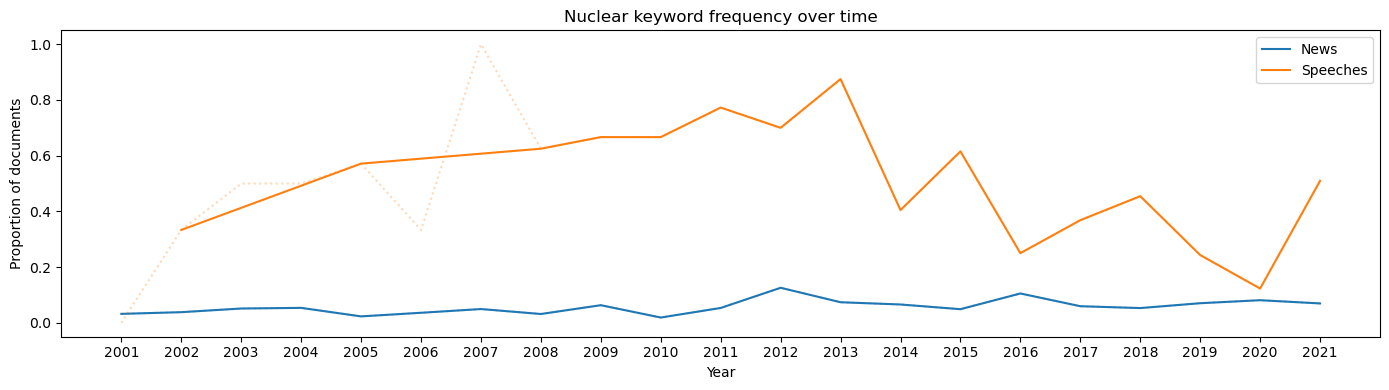

In [15]:
plot_category('nuclear', news_results, speech_results, labels=['News', 'Speeches'])

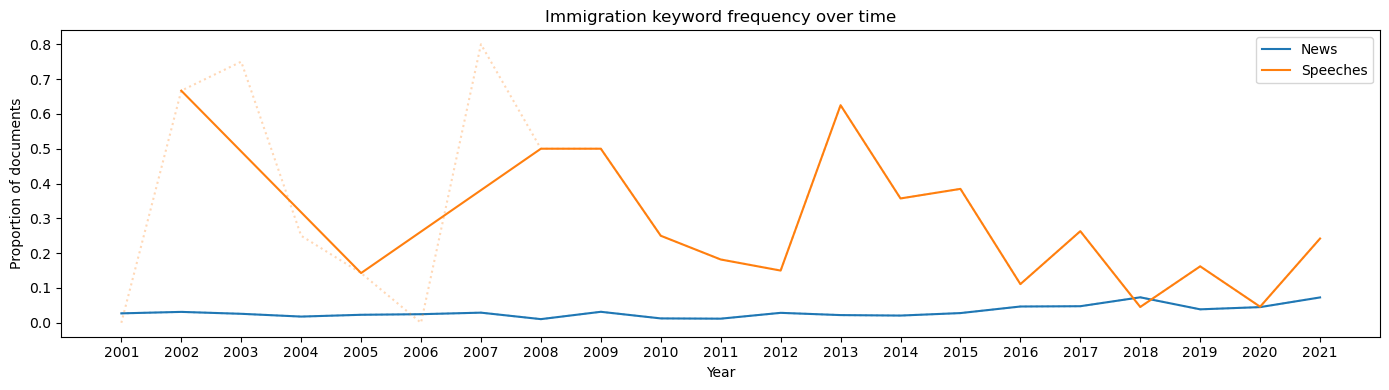

In [16]:
plot_category('immigration', news_results, speech_results, labels=['News', 'Speeches'])